# 04 — MOSFET Selection

**Project:** USB-C PD → 12 V fan-array controller (LM5176 4-switch buck-boost, 42 W)

**Purpose:** Rank candidate MOSFETs by total loss (conduction + switching + gate drive) at the worst-case operating point (5 V in → 12 V out boost, ~13.5 W), with the 47 µH inductor chosen in notebook 03.

**Key result / decision:** **BSC0902NS** — best balance of R_DS(on) and gate charge at the LM5176's 7.35 V gate drive.

**See also:** 03 (inductor selection), 01 (power budget).

## Loss model and ranking

Per-part loss breakdown at V_in = 5 V (boost, worst case).

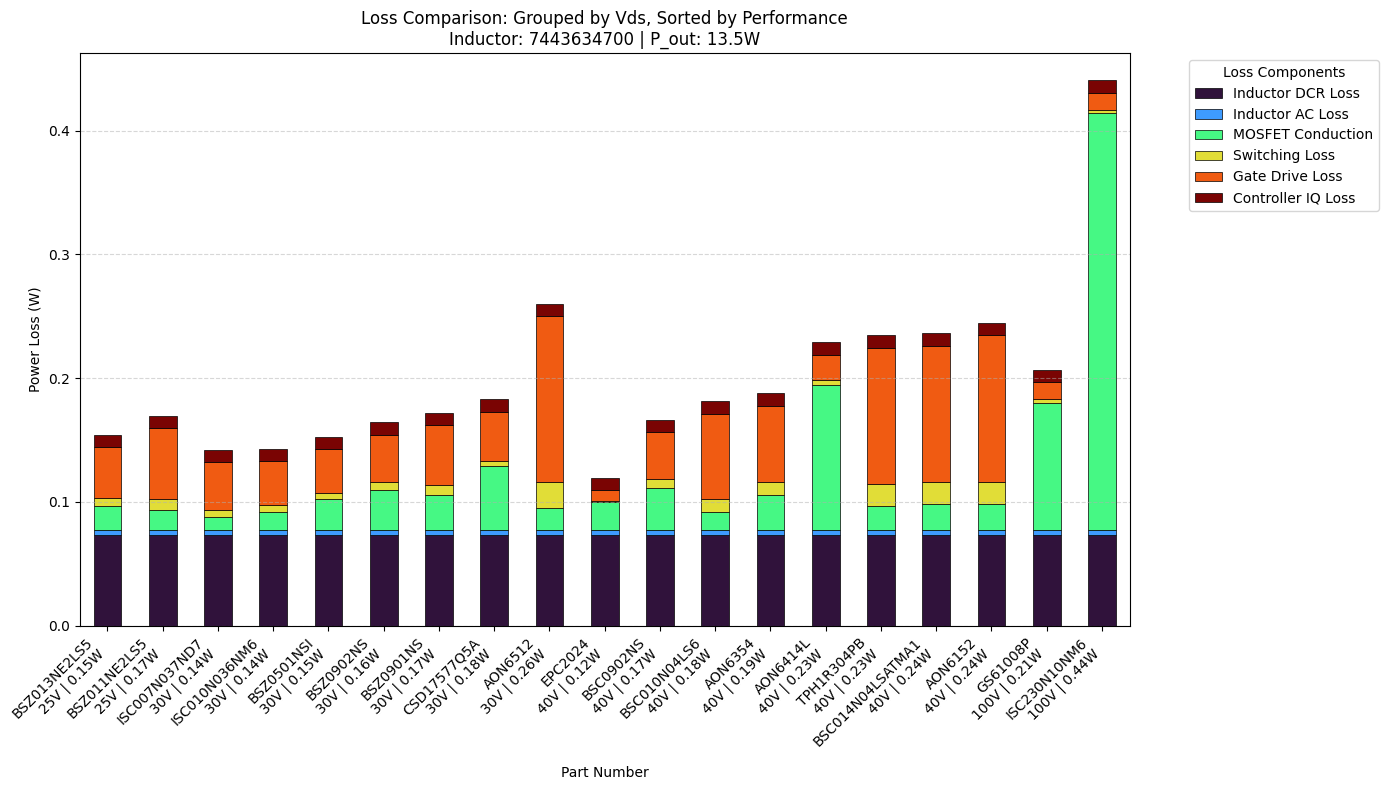

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load part database (see data/)
ind_df = pd.read_csv('../data/inductors.csv')
mos_df = pd.read_csv('../data/mosfets.csv')
mos_df = mos_df.rename(columns={'Part_Number': 'Part Number'})

# --- CONFIGURATION ---
target_pn = '7443634700'
inductor = {'Inductance_uH': 47, 'DCR_max_mOhm': 10, 'Rp_Ohm': 8000} 

v_in = 5.0
v_out = 12.0
f_sw = 100e3
v_gate = 7.35
i_gate_src = 1.8
i_gate_snk = 2.2
i_q = 2e-3
i_in_limit = 3.0
est_eff = 0.9
p_out = v_in * i_in_limit * est_eff

def get_loss_breakdown(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, rp=None):
    i_out = p_out / v_out
    d = 1 - (v_in / v_out) 
    i_l_avg = i_out / (1 - d)
    delta_il = (v_in * d) / (L * f_sw)
    v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    p_dcr = i_l_rms**2 * dcr
    p_ac = ( (v_in**2 * d) + ((v_in - v_out)**2 * (1-d)) ) / rp if (rp and rp > 0) else 0.0
    p_cond = i_l_rms**2 * (rdson * 2) 
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    return {
        'Inductor DCR Loss': p_dcr,
        'Inductor AC Loss': p_ac,
        'MOSFET Conduction': p_cond,
        'Switching Loss': p_sw,
        'Gate Drive Loss': p_gate,
        'Controller IQ Loss': p_ic
    }

# --- CALCULATION LOOP ---
results = []
for _, mos in mos_df.iterrows():
    rdson = (mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(mos['RDSon_10V_Typ(mOhm)']) else mos['RDSon_4.5V_Typ(mOhm)']) * 1e-3
    qg = (mos['Qg_10V_Typ(nC)'] if not pd.isna(mos['Qg_10V_Typ(nC)']) else mos['Qg_4.5V_Typ(nC)']) * 1e-9
    qgd = mos['Qgd_Typ(nC)'] * 1e-9
    
    loss = get_loss_breakdown(
        v_in, v_out, p_out, 
        inductor['Inductance_uH']*1e-6, inductor['DCR_max_mOhm']*1e-3, 
        rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, 
        rp=inductor.get('Rp_Ohm')
    )
    loss['Part Number'] = mos['Part Number']
    loss['VDS_Max'] = mos['VDS_Max(V)']
    results.append(loss)

# --- DATAFRAME PROCESSING & SORTING ---
df_results = pd.DataFrame(results)

# 1. Identify loss columns
metadata_cols = ['Part Number', 'VDS_Max']
loss_cols = [c for c in df_results.columns if c not in metadata_cols]

# 2. Calculate Total Loss
df_results['Total Loss'] = df_results[loss_cols].sum(axis=1)

# 3. GROUP BY VDS, THEN SORT BY LOSS
# This sorts the DF primarily by VDS (low to high), then by loss within each voltage tier
df_results = df_results.sort_values(by=['VDS_Max', 'Total Loss'], ascending=[True, True])

# 4. Prepare plot data
df_plot = df_results.set_index('Part Number')[loss_cols]

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 8))
df_plot.plot(kind='bar', stacked=True, ax=ax, colormap='turbo', edgecolor='black', linewidth=0.5)

# Create labels that highlight the grouping
new_labels = [
    f"{row['Part Number']}\n{row['VDS_Max']}V | {row['Total Loss']:.2f}W" 
    for _, row in df_results.iterrows()
]
ax.set_xticklabels(new_labels, rotation=45, ha='right')

ax.set_title(f"Loss Comparison: Grouped by Vds, Sorted by Performance\nInductor: {target_pn} | P_out: {p_out:.1f}W")
ax.set_ylabel("Power Loss (W)")
ax.legend(title="Loss Components", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Final Conclusions

In [2]:
mosfet_choice = "BSC0902NS"